# Fashion MNIST GAN Presentation

### Introduction
This project implements a Conditional Generative Adversarial Network (GAN) using the Fashion MNIST dataset. The goal is to generate new fashion items based on specific class labels, allowing for the generation of images that correspond to different categories of clothing.

### Setup Instructions
To run this notebook, ensure you have the following packages installed. This notebook was trained on **PyTorch version 2.6.0+cu126 with CUDA 12.6.** Run the following commands in your terminal:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

### Import Necessary Libraries
The following libraries are imported for the implementation:

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os


### Check CUDA Availability
The code checks if CUDA is available for GPU acceleration:

In [2]:
print(f"Pytorch Version: {torch.__version__}")
print(f"Cuda version: {torch.version.cuda}")
print(f"Is CUDA version availaible: {torch.cuda.is_available()}")

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Pytorch Version: 2.6.0+cu126
Cuda version: 12.6
Is CUDA version availaible: True
Using device: cuda


### Hyperparameters
The following hyperparameters are defined for the training process:

In [8]:

# Hyperparameters
batch_size = 128
latent_dim = 150
lr = 0.0006
epochs = 500
num_classes = 10


### Load MNIST Dataset
The Fashion MNIST dataset is loaded and transformed:

In [9]:

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)



### Model Architecture

#### Conditional Generator
The Conditional Generator is defined as follows:

In [ ]:
class ConditionalGenerator(nn.Module):  # Changed from Generator
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        return self.model(x).view(-1, 1, 28, 28)



#### Conditional Discriminator
The Conditional Discriminator is defined as follows:


In [10]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_emb(labels)
        x = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(x)

### Training Process
The training loop consists of alternating between training the discriminator and the generator. The loss functions used are Binary Cross Entropy Loss.

[Epoch 1/500] D_loss: 0.0013 G_loss: 21.4604
[Epoch 2/500] D_loss: 0.0627 G_loss: 37.6167
[Epoch 3/500] D_loss: 0.0155 G_loss: 52.6820
[Epoch 4/500] D_loss: 0.0005 G_loss: 47.7002
[Epoch 5/500] D_loss: 0.0001 G_loss: 46.8276
[Epoch 6/500] D_loss: 0.0000 G_loss: 66.6278
[Epoch 7/500] D_loss: 0.0007 G_loss: 68.3549
[Epoch 8/500] D_loss: 0.0094 G_loss: 45.6392
[Epoch 9/500] D_loss: 0.0039 G_loss: 55.7878
[Epoch 10/500] D_loss: 0.0006 G_loss: 89.3064
[Epoch 11/500] D_loss: 0.0000 G_loss: 85.1020
[Epoch 12/500] D_loss: 0.0000 G_loss: 84.1801
[Epoch 13/500] D_loss: 0.0000 G_loss: 84.9638
[Epoch 14/500] D_loss: 0.0000 G_loss: 89.7873
[Epoch 15/500] D_loss: 0.0000 G_loss: 84.3500
[Epoch 16/500] D_loss: 0.0247 G_loss: 29.1831
[Epoch 17/500] D_loss: 0.0045 G_loss: 53.9104
[Epoch 18/500] D_loss: 0.0395 G_loss: 44.0690
[Epoch 19/500] D_loss: 0.0533 G_loss: 24.3076
[Epoch 20/500] D_loss: 0.0050 G_loss: 24.5398


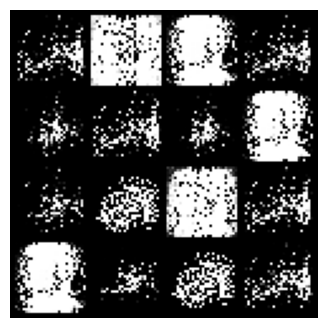

[Epoch 21/500] D_loss: 0.0010 G_loss: 24.6696
[Epoch 22/500] D_loss: 0.0042 G_loss: 29.8808
[Epoch 23/500] D_loss: 0.0346 G_loss: 12.2110
[Epoch 24/500] D_loss: 0.0001 G_loss: 18.1164
[Epoch 25/500] D_loss: 0.0182 G_loss: 13.6630
[Epoch 26/500] D_loss: 0.0688 G_loss: 12.8983
[Epoch 27/500] D_loss: 0.0575 G_loss: 18.8454
[Epoch 28/500] D_loss: 0.0877 G_loss: 13.5013
[Epoch 29/500] D_loss: 0.0218 G_loss: 10.8980
[Epoch 30/500] D_loss: 0.0039 G_loss: 39.6717
[Epoch 31/500] D_loss: 0.0098 G_loss: 15.3175
[Epoch 32/500] D_loss: 0.0259 G_loss: 14.8530
[Epoch 33/500] D_loss: 0.2636 G_loss: 9.0177
[Epoch 34/500] D_loss: 0.0934 G_loss: 8.2550
[Epoch 35/500] D_loss: 0.2076 G_loss: 8.8895
[Epoch 36/500] D_loss: 0.1606 G_loss: 9.0589
[Epoch 37/500] D_loss: 0.1333 G_loss: 7.6057
[Epoch 38/500] D_loss: 0.2570 G_loss: 8.1287
[Epoch 39/500] D_loss: 0.2613 G_loss: 9.0505
[Epoch 40/500] D_loss: 0.2660 G_loss: 6.8789


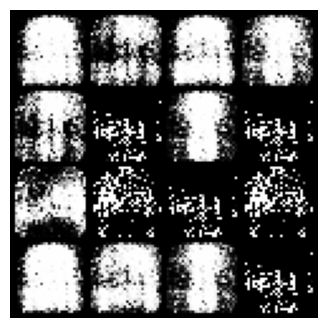

[Epoch 41/500] D_loss: 0.4528 G_loss: 5.4203
[Epoch 42/500] D_loss: 0.1739 G_loss: 7.7289
[Epoch 43/500] D_loss: 0.5628 G_loss: 6.8879
[Epoch 44/500] D_loss: 0.4976 G_loss: 4.7671
[Epoch 45/500] D_loss: 0.3728 G_loss: 7.3087
[Epoch 46/500] D_loss: 0.4389 G_loss: 7.7891
[Epoch 47/500] D_loss: 0.4199 G_loss: 5.8597
[Epoch 48/500] D_loss: 0.6015 G_loss: 6.0504
[Epoch 49/500] D_loss: 0.6933 G_loss: 4.3615
[Epoch 50/500] D_loss: 0.7137 G_loss: 4.7798
[Epoch 51/500] D_loss: 0.3886 G_loss: 5.7711
[Epoch 52/500] D_loss: 0.5528 G_loss: 5.4632
[Epoch 53/500] D_loss: 0.9734 G_loss: 4.3642
[Epoch 54/500] D_loss: 0.5515 G_loss: 3.5204
[Epoch 55/500] D_loss: 0.7645 G_loss: 4.2670
[Epoch 56/500] D_loss: 0.8259 G_loss: 4.5637
[Epoch 57/500] D_loss: 0.6515 G_loss: 6.2365
[Epoch 58/500] D_loss: 0.9022 G_loss: 3.9894
[Epoch 59/500] D_loss: 0.7512 G_loss: 4.3311
[Epoch 60/500] D_loss: 0.6793 G_loss: 4.1399


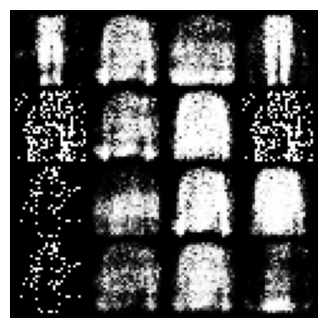

[Epoch 61/500] D_loss: 0.4040 G_loss: 4.6754
[Epoch 62/500] D_loss: 0.5666 G_loss: 5.7352
[Epoch 63/500] D_loss: 0.5633 G_loss: 4.5876
[Epoch 64/500] D_loss: 0.7154 G_loss: 3.9909
[Epoch 65/500] D_loss: 0.8196 G_loss: 4.9754
[Epoch 66/500] D_loss: 0.6105 G_loss: 3.7888
[Epoch 67/500] D_loss: 0.8331 G_loss: 2.7606
[Epoch 68/500] D_loss: 0.8048 G_loss: 2.4258
[Epoch 69/500] D_loss: 0.7421 G_loss: 4.0343
[Epoch 70/500] D_loss: 0.6059 G_loss: 3.8183
[Epoch 71/500] D_loss: 0.5425 G_loss: 3.5200
[Epoch 72/500] D_loss: 0.7013 G_loss: 3.3254
[Epoch 73/500] D_loss: 0.7045 G_loss: 3.9396
[Epoch 74/500] D_loss: 0.5687 G_loss: 4.0914
[Epoch 75/500] D_loss: 0.7300 G_loss: 5.4771
[Epoch 76/500] D_loss: 0.8106 G_loss: 3.0871
[Epoch 77/500] D_loss: 0.9233 G_loss: 2.5381
[Epoch 78/500] D_loss: 0.7787 G_loss: 3.3917
[Epoch 79/500] D_loss: 0.6859 G_loss: 3.5481
[Epoch 80/500] D_loss: 0.6066 G_loss: 3.9808


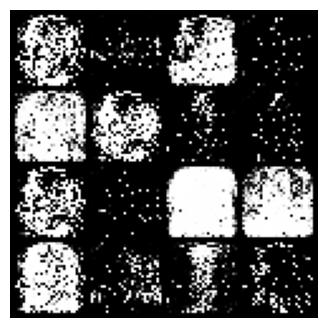

[Epoch 81/500] D_loss: 0.6434 G_loss: 3.0724
[Epoch 82/500] D_loss: 0.7059 G_loss: 2.5724
[Epoch 83/500] D_loss: 0.7392 G_loss: 4.4072
[Epoch 84/500] D_loss: 0.5640 G_loss: 3.6552
[Epoch 85/500] D_loss: 0.8418 G_loss: 3.3834
[Epoch 86/500] D_loss: 0.7723 G_loss: 3.0415
[Epoch 87/500] D_loss: 0.6905 G_loss: 4.2802
[Epoch 88/500] D_loss: 0.8190 G_loss: 2.2910
[Epoch 89/500] D_loss: 0.9821 G_loss: 3.1735
[Epoch 90/500] D_loss: 0.8186 G_loss: 2.8231
[Epoch 91/500] D_loss: 0.8612 G_loss: 3.1098
[Epoch 92/500] D_loss: 0.5221 G_loss: 3.1978
[Epoch 93/500] D_loss: 0.9953 G_loss: 2.2490
[Epoch 94/500] D_loss: 0.7094 G_loss: 3.7867
[Epoch 95/500] D_loss: 0.6391 G_loss: 4.0508
[Epoch 96/500] D_loss: 1.1630 G_loss: 1.6339
[Epoch 97/500] D_loss: 0.7755 G_loss: 3.8715
[Epoch 98/500] D_loss: 0.9124 G_loss: 2.1100
[Epoch 99/500] D_loss: 0.6665 G_loss: 3.6684
[Epoch 100/500] D_loss: 0.7566 G_loss: 4.7061


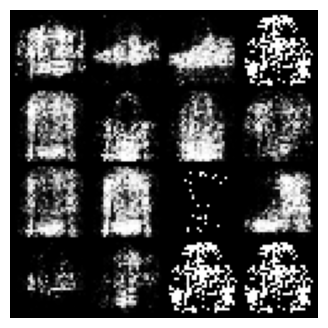

[Epoch 101/500] D_loss: 1.0092 G_loss: 2.6723
[Epoch 102/500] D_loss: 0.4184 G_loss: 4.1166
[Epoch 103/500] D_loss: 0.7958 G_loss: 3.8555
[Epoch 104/500] D_loss: 0.8904 G_loss: 2.5313
[Epoch 105/500] D_loss: 0.7602 G_loss: 3.5203
[Epoch 106/500] D_loss: 0.6078 G_loss: 3.2549
[Epoch 107/500] D_loss: 0.6185 G_loss: 3.4336
[Epoch 108/500] D_loss: 0.6865 G_loss: 3.1186
[Epoch 109/500] D_loss: 0.7807 G_loss: 3.8781
[Epoch 110/500] D_loss: 0.6671 G_loss: 3.9379
[Epoch 111/500] D_loss: 1.0097 G_loss: 2.1550
[Epoch 112/500] D_loss: 0.6193 G_loss: 3.4424
[Epoch 113/500] D_loss: 0.7463 G_loss: 4.0331
[Epoch 114/500] D_loss: 0.7805 G_loss: 3.2905
[Epoch 115/500] D_loss: 0.9180 G_loss: 1.8404
[Epoch 116/500] D_loss: 0.5270 G_loss: 2.8930
[Epoch 117/500] D_loss: 0.6181 G_loss: 3.1617
[Epoch 118/500] D_loss: 1.1307 G_loss: 2.3355
[Epoch 119/500] D_loss: 0.8903 G_loss: 4.3483
[Epoch 120/500] D_loss: 0.9426 G_loss: 3.3120


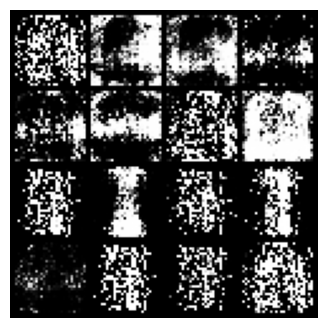

[Epoch 121/500] D_loss: 0.7988 G_loss: 2.2264
[Epoch 122/500] D_loss: 1.0998 G_loss: 2.3360
[Epoch 123/500] D_loss: 0.8572 G_loss: 2.3614
[Epoch 124/500] D_loss: 1.2263 G_loss: 3.5257
[Epoch 125/500] D_loss: 0.9913 G_loss: 3.2878
[Epoch 126/500] D_loss: 0.9223 G_loss: 1.8367
[Epoch 127/500] D_loss: 0.6405 G_loss: 2.8223
[Epoch 128/500] D_loss: 0.8526 G_loss: 2.7872
[Epoch 129/500] D_loss: 0.8242 G_loss: 2.0130
[Epoch 130/500] D_loss: 0.8931 G_loss: 2.3348
[Epoch 131/500] D_loss: 0.9351 G_loss: 2.6866
[Epoch 132/500] D_loss: 0.8486 G_loss: 3.7081
[Epoch 133/500] D_loss: 0.8682 G_loss: 3.5347
[Epoch 134/500] D_loss: 0.9902 G_loss: 3.6400
[Epoch 135/500] D_loss: 1.1796 G_loss: 4.3927
[Epoch 136/500] D_loss: 0.8498 G_loss: 2.7544
[Epoch 137/500] D_loss: 0.9151 G_loss: 1.9367
[Epoch 138/500] D_loss: 0.9286 G_loss: 2.2780
[Epoch 139/500] D_loss: 0.8103 G_loss: 3.2275
[Epoch 140/500] D_loss: 0.8382 G_loss: 2.5994


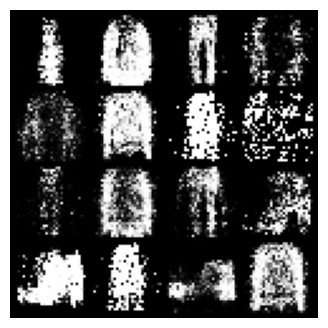

[Epoch 141/500] D_loss: 0.5618 G_loss: 3.6615
[Epoch 142/500] D_loss: 0.9188 G_loss: 2.6467
[Epoch 143/500] D_loss: 1.2130 G_loss: 2.5129
[Epoch 144/500] D_loss: 0.8631 G_loss: 2.9323
[Epoch 145/500] D_loss: 0.8690 G_loss: 2.5867
[Epoch 146/500] D_loss: 1.0409 G_loss: 2.0562
[Epoch 147/500] D_loss: 1.0136 G_loss: 2.5297
[Epoch 148/500] D_loss: 0.5646 G_loss: 3.8673
[Epoch 149/500] D_loss: 0.9061 G_loss: 2.8830
[Epoch 150/500] D_loss: 0.9669 G_loss: 2.1155
[Epoch 151/500] D_loss: 1.0627 G_loss: 1.9123
[Epoch 152/500] D_loss: 0.7553 G_loss: 2.8754
[Epoch 153/500] D_loss: 1.0263 G_loss: 3.2078
[Epoch 154/500] D_loss: 0.9845 G_loss: 2.1968
[Epoch 155/500] D_loss: 1.1016 G_loss: 1.7620
[Epoch 156/500] D_loss: 1.1164 G_loss: 2.7941
[Epoch 157/500] D_loss: 0.8800 G_loss: 1.7283
[Epoch 158/500] D_loss: 0.8064 G_loss: 2.1594
[Epoch 159/500] D_loss: 0.7166 G_loss: 2.5386
[Epoch 160/500] D_loss: 1.5914 G_loss: 1.2780


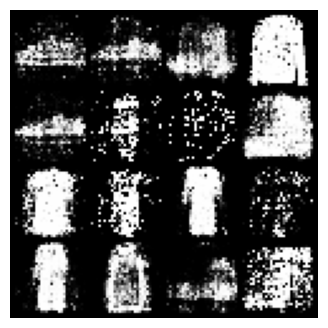

[Epoch 161/500] D_loss: 0.9244 G_loss: 2.1741
[Epoch 162/500] D_loss: 1.1839 G_loss: 3.2825
[Epoch 163/500] D_loss: 1.0983 G_loss: 2.4018
[Epoch 164/500] D_loss: 1.0655 G_loss: 2.3846
[Epoch 165/500] D_loss: 1.1914 G_loss: 1.9314
[Epoch 166/500] D_loss: 1.4152 G_loss: 2.3925
[Epoch 167/500] D_loss: 1.2556 G_loss: 1.4720
[Epoch 168/500] D_loss: 0.6974 G_loss: 2.7036
[Epoch 169/500] D_loss: 0.6541 G_loss: 2.3501
[Epoch 170/500] D_loss: 1.3283 G_loss: 1.6849
[Epoch 171/500] D_loss: 1.0958 G_loss: 1.5934
[Epoch 172/500] D_loss: 1.5481 G_loss: 2.8161
[Epoch 173/500] D_loss: 1.7974 G_loss: 2.1425
[Epoch 174/500] D_loss: 1.2186 G_loss: 1.6147
[Epoch 175/500] D_loss: 1.2217 G_loss: 1.8650
[Epoch 176/500] D_loss: 1.1010 G_loss: 1.5072
[Epoch 177/500] D_loss: 1.1966 G_loss: 1.7258
[Epoch 178/500] D_loss: 1.1534 G_loss: 1.3329
[Epoch 179/500] D_loss: 0.8647 G_loss: 1.8864
[Epoch 180/500] D_loss: 1.1244 G_loss: 1.6024


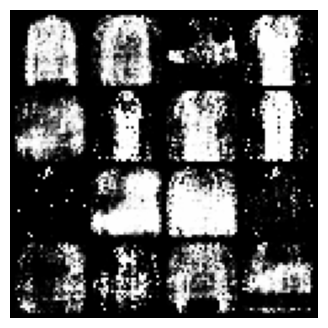

[Epoch 181/500] D_loss: 0.9338 G_loss: 2.5729
[Epoch 182/500] D_loss: 1.2156 G_loss: 1.1645
[Epoch 183/500] D_loss: 0.9587 G_loss: 1.9680
[Epoch 184/500] D_loss: 1.5733 G_loss: 1.6896
[Epoch 185/500] D_loss: 1.2180 G_loss: 1.4894
[Epoch 186/500] D_loss: 0.8419 G_loss: 2.9440
[Epoch 187/500] D_loss: 1.2098 G_loss: 1.8831
[Epoch 188/500] D_loss: 1.0014 G_loss: 2.0258
[Epoch 189/500] D_loss: 1.1237 G_loss: 1.6840
[Epoch 190/500] D_loss: 1.4968 G_loss: 1.8012
[Epoch 191/500] D_loss: 1.4965 G_loss: 2.1037
[Epoch 192/500] D_loss: 1.3169 G_loss: 1.4856
[Epoch 193/500] D_loss: 1.9978 G_loss: 1.5462
[Epoch 194/500] D_loss: 1.1453 G_loss: 1.3937
[Epoch 195/500] D_loss: 0.7778 G_loss: 2.6175
[Epoch 196/500] D_loss: 1.3334 G_loss: 2.4755
[Epoch 197/500] D_loss: 0.8766 G_loss: 1.6463
[Epoch 198/500] D_loss: 1.2724 G_loss: 2.1532
[Epoch 199/500] D_loss: 1.7077 G_loss: 1.7063
[Epoch 200/500] D_loss: 1.0529 G_loss: 1.7001


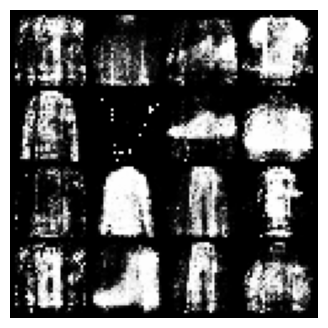

[Epoch 201/500] D_loss: 1.0106 G_loss: 3.1706
[Epoch 202/500] D_loss: 1.3751 G_loss: 1.1924
[Epoch 203/500] D_loss: 0.9273 G_loss: 3.3860
[Epoch 204/500] D_loss: 1.0920 G_loss: 1.6857
[Epoch 205/500] D_loss: 1.0986 G_loss: 2.0115
[Epoch 206/500] D_loss: 1.0324 G_loss: 1.2323
[Epoch 207/500] D_loss: 0.9755 G_loss: 2.3680
[Epoch 208/500] D_loss: 0.8256 G_loss: 2.6549
[Epoch 209/500] D_loss: 1.0624 G_loss: 1.8115
[Epoch 210/500] D_loss: 1.1613 G_loss: 2.0640
[Epoch 211/500] D_loss: 1.5100 G_loss: 1.5044
[Epoch 212/500] D_loss: 0.8762 G_loss: 1.7477
[Epoch 213/500] D_loss: 1.2985 G_loss: 1.2706
[Epoch 214/500] D_loss: 0.9288 G_loss: 1.9704
[Epoch 215/500] D_loss: 1.4494 G_loss: 2.0525
[Epoch 216/500] D_loss: 1.1185 G_loss: 1.5630
[Epoch 217/500] D_loss: 1.8457 G_loss: 2.3099
[Epoch 218/500] D_loss: 1.1582 G_loss: 1.7118
[Epoch 219/500] D_loss: 1.2733 G_loss: 2.0011
[Epoch 220/500] D_loss: 1.8506 G_loss: 1.5000


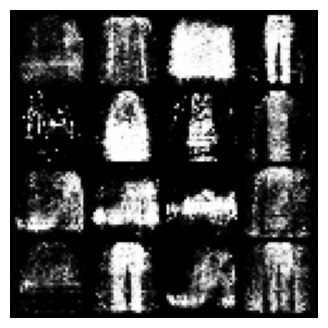

[Epoch 221/500] D_loss: 1.1673 G_loss: 1.7469
[Epoch 222/500] D_loss: 0.9668 G_loss: 2.5297
[Epoch 223/500] D_loss: 1.3367 G_loss: 1.7875
[Epoch 224/500] D_loss: 1.6326 G_loss: 1.4501
[Epoch 225/500] D_loss: 1.3232 G_loss: 1.7444
[Epoch 226/500] D_loss: 0.9616 G_loss: 1.4433
[Epoch 227/500] D_loss: 2.0211 G_loss: 1.8557
[Epoch 228/500] D_loss: 1.5501 G_loss: 1.3213
[Epoch 229/500] D_loss: 1.7173 G_loss: 1.4166
[Epoch 230/500] D_loss: 1.0288 G_loss: 1.5022
[Epoch 231/500] D_loss: 1.0360 G_loss: 1.8391
[Epoch 232/500] D_loss: 1.0798 G_loss: 1.4597
[Epoch 233/500] D_loss: 1.5115 G_loss: 1.7146
[Epoch 234/500] D_loss: 1.3953 G_loss: 1.3196
[Epoch 235/500] D_loss: 1.1213 G_loss: 1.9977
[Epoch 236/500] D_loss: 2.4403 G_loss: 1.3266
[Epoch 237/500] D_loss: 1.0415 G_loss: 2.2504
[Epoch 238/500] D_loss: 1.0877 G_loss: 1.6389
[Epoch 239/500] D_loss: 1.1595 G_loss: 1.4402
[Epoch 240/500] D_loss: 1.0920 G_loss: 1.7292


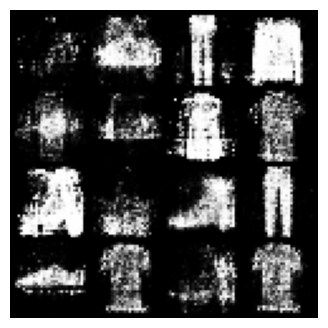

[Epoch 241/500] D_loss: 1.3875 G_loss: 2.4385
[Epoch 242/500] D_loss: 1.1202 G_loss: 1.4925
[Epoch 243/500] D_loss: 1.7975 G_loss: 1.4055
[Epoch 244/500] D_loss: 1.3551 G_loss: 1.6486
[Epoch 245/500] D_loss: 1.2541 G_loss: 1.3615
[Epoch 246/500] D_loss: 1.4288 G_loss: 1.9005
[Epoch 247/500] D_loss: 1.0609 G_loss: 1.8752
[Epoch 248/500] D_loss: 1.0151 G_loss: 3.0516
[Epoch 249/500] D_loss: 1.1431 G_loss: 1.5313
[Epoch 250/500] D_loss: 1.2397 G_loss: 1.5349
[Epoch 251/500] D_loss: 1.1690 G_loss: 1.5351
[Epoch 252/500] D_loss: 1.2526 G_loss: 1.8264
[Epoch 253/500] D_loss: 0.8858 G_loss: 2.2622
[Epoch 254/500] D_loss: 1.2075 G_loss: 1.2403
[Epoch 255/500] D_loss: 1.4616 G_loss: 1.6604
[Epoch 256/500] D_loss: 1.0955 G_loss: 1.4915
[Epoch 257/500] D_loss: 1.5302 G_loss: 2.1547
[Epoch 258/500] D_loss: 1.2149 G_loss: 1.3408
[Epoch 259/500] D_loss: 1.2606 G_loss: 1.6422
[Epoch 260/500] D_loss: 1.3130 G_loss: 1.7492


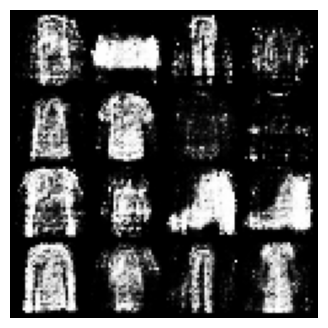

[Epoch 261/500] D_loss: 1.1134 G_loss: 1.6565
[Epoch 262/500] D_loss: 0.6318 G_loss: 5.0779
[Epoch 263/500] D_loss: 0.9565 G_loss: 1.5514
[Epoch 264/500] D_loss: 0.8301 G_loss: 2.7511
[Epoch 265/500] D_loss: 1.1119 G_loss: 1.5322
[Epoch 266/500] D_loss: 1.5551 G_loss: 1.6533
[Epoch 267/500] D_loss: 1.0533 G_loss: 1.3224
[Epoch 268/500] D_loss: 0.7778 G_loss: 2.2013
[Epoch 269/500] D_loss: 1.3483 G_loss: 1.4223
[Epoch 270/500] D_loss: 0.5731 G_loss: 3.2414
[Epoch 271/500] D_loss: 1.2893 G_loss: 1.2955
[Epoch 272/500] D_loss: 1.2285 G_loss: 1.4457
[Epoch 273/500] D_loss: 1.8363 G_loss: 1.3942
[Epoch 274/500] D_loss: 1.1259 G_loss: 2.9292
[Epoch 275/500] D_loss: 1.2466 G_loss: 1.5266
[Epoch 276/500] D_loss: 1.1074 G_loss: 1.3482
[Epoch 277/500] D_loss: 2.0457 G_loss: 1.8570
[Epoch 278/500] D_loss: 1.1323 G_loss: 1.6766
[Epoch 279/500] D_loss: 2.3636 G_loss: 1.7392
[Epoch 280/500] D_loss: 0.9532 G_loss: 1.4828


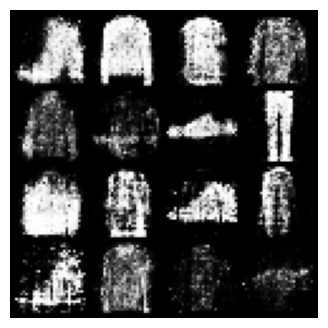

[Epoch 281/500] D_loss: 1.3353 G_loss: 1.5564
[Epoch 282/500] D_loss: 0.9274 G_loss: 1.8311
[Epoch 283/500] D_loss: 1.0213 G_loss: 1.3706
[Epoch 284/500] D_loss: 1.8716 G_loss: 1.0145
[Epoch 285/500] D_loss: 1.3840 G_loss: 2.5948
[Epoch 286/500] D_loss: 0.9371 G_loss: 1.9537
[Epoch 287/500] D_loss: 0.9759 G_loss: 2.1657
[Epoch 288/500] D_loss: 1.0092 G_loss: 1.6880
[Epoch 289/500] D_loss: 1.9223 G_loss: 1.5855
[Epoch 290/500] D_loss: 1.0105 G_loss: 1.9586
[Epoch 291/500] D_loss: 1.1915 G_loss: 3.1672
[Epoch 292/500] D_loss: 0.9735 G_loss: 1.4857
[Epoch 293/500] D_loss: 1.5177 G_loss: 1.3897
[Epoch 294/500] D_loss: 1.2157 G_loss: 1.3668
[Epoch 295/500] D_loss: 1.7055 G_loss: 2.2670
[Epoch 296/500] D_loss: 1.2343 G_loss: 1.2570
[Epoch 297/500] D_loss: 0.8011 G_loss: 2.2139
[Epoch 298/500] D_loss: 1.2372 G_loss: 2.1374
[Epoch 299/500] D_loss: 1.8978 G_loss: 1.1709
[Epoch 300/500] D_loss: 1.4768 G_loss: 1.6560


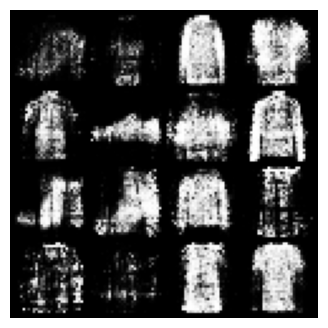

[Epoch 301/500] D_loss: 1.4616 G_loss: 2.1306
[Epoch 302/500] D_loss: 1.4501 G_loss: 1.2148
[Epoch 303/500] D_loss: 1.8491 G_loss: 2.3596
[Epoch 304/500] D_loss: 0.9582 G_loss: 1.8312
[Epoch 305/500] D_loss: 1.0762 G_loss: 1.6582
[Epoch 306/500] D_loss: 1.1380 G_loss: 1.8279
[Epoch 307/500] D_loss: 0.9678 G_loss: 1.4895
[Epoch 308/500] D_loss: 1.3878 G_loss: 1.3865
[Epoch 309/500] D_loss: 1.2876 G_loss: 1.4630
[Epoch 310/500] D_loss: 1.2116 G_loss: 1.2756
[Epoch 311/500] D_loss: 0.7145 G_loss: 4.1973
[Epoch 312/500] D_loss: 1.2281 G_loss: 1.3554
[Epoch 313/500] D_loss: 1.0880 G_loss: 1.6526
[Epoch 314/500] D_loss: 1.1841 G_loss: 2.0644
[Epoch 315/500] D_loss: 1.1536 G_loss: 1.7169
[Epoch 316/500] D_loss: 1.3575 G_loss: 1.2806
[Epoch 317/500] D_loss: 1.2689 G_loss: 2.3138
[Epoch 318/500] D_loss: 1.2085 G_loss: 1.2237
[Epoch 319/500] D_loss: 1.6921 G_loss: 2.2855
[Epoch 320/500] D_loss: 1.0792 G_loss: 1.4800


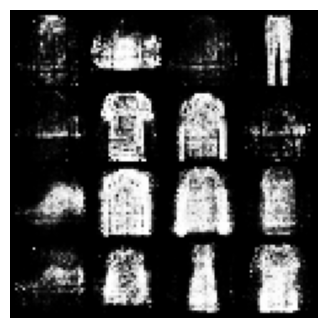

[Epoch 321/500] D_loss: 1.0168 G_loss: 3.1265
[Epoch 322/500] D_loss: 1.1912 G_loss: 1.1962
[Epoch 323/500] D_loss: 1.0634 G_loss: 1.7816
[Epoch 324/500] D_loss: 0.6590 G_loss: 2.9534
[Epoch 325/500] D_loss: 1.0773 G_loss: 2.4111
[Epoch 326/500] D_loss: 1.0108 G_loss: 2.1164
[Epoch 327/500] D_loss: 1.4132 G_loss: 1.3223
[Epoch 328/500] D_loss: 1.2411 G_loss: 1.3010
[Epoch 329/500] D_loss: 1.2227 G_loss: 1.6227
[Epoch 330/500] D_loss: 1.3267 G_loss: 1.3624
[Epoch 331/500] D_loss: 1.3005 G_loss: 1.3985
[Epoch 332/500] D_loss: 1.5357 G_loss: 2.0607
[Epoch 333/500] D_loss: 1.2525 G_loss: 3.0785
[Epoch 334/500] D_loss: 0.9987 G_loss: 1.7130
[Epoch 335/500] D_loss: 1.2032 G_loss: 1.7651
[Epoch 336/500] D_loss: 1.5368 G_loss: 1.2183
[Epoch 337/500] D_loss: 1.1747 G_loss: 1.9093
[Epoch 338/500] D_loss: 1.1325 G_loss: 1.6592
[Epoch 339/500] D_loss: 1.0729 G_loss: 2.0073
[Epoch 340/500] D_loss: 1.2213 G_loss: 1.3126


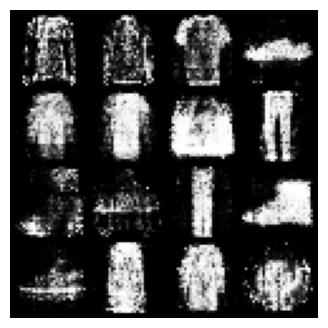

[Epoch 341/500] D_loss: 1.3867 G_loss: 2.5872
[Epoch 342/500] D_loss: 1.1503 G_loss: 2.0764
[Epoch 343/500] D_loss: 0.6810 G_loss: 2.9934
[Epoch 344/500] D_loss: 1.0481 G_loss: 1.8435
[Epoch 345/500] D_loss: 1.1525 G_loss: 1.7001
[Epoch 346/500] D_loss: 1.7485 G_loss: 2.2237
[Epoch 347/500] D_loss: 1.4717 G_loss: 1.1262
[Epoch 348/500] D_loss: 1.7207 G_loss: 1.4940
[Epoch 349/500] D_loss: 1.4693 G_loss: 1.4413
[Epoch 350/500] D_loss: 1.0877 G_loss: 1.5589
[Epoch 351/500] D_loss: 1.0107 G_loss: 1.5589
[Epoch 352/500] D_loss: 1.4097 G_loss: 1.6132
[Epoch 353/500] D_loss: 1.8226 G_loss: 1.3059
[Epoch 354/500] D_loss: 1.2850 G_loss: 1.1338
[Epoch 355/500] D_loss: 1.1585 G_loss: 1.9244
[Epoch 356/500] D_loss: 1.3880 G_loss: 1.8863
[Epoch 357/500] D_loss: 1.4284 G_loss: 1.5790
[Epoch 358/500] D_loss: 1.4374 G_loss: 1.5755
[Epoch 359/500] D_loss: 1.4075 G_loss: 1.7821
[Epoch 360/500] D_loss: 1.1175 G_loss: 1.5012


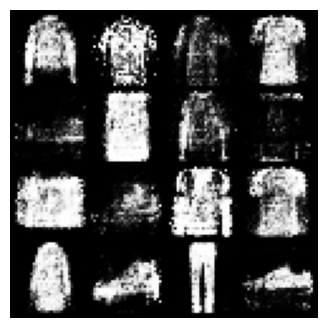

[Epoch 361/500] D_loss: 1.2454 G_loss: 1.4609
[Epoch 362/500] D_loss: 1.2015 G_loss: 2.0424
[Epoch 363/500] D_loss: 1.1343 G_loss: 1.4304
[Epoch 364/500] D_loss: 1.2013 G_loss: 1.4788
[Epoch 365/500] D_loss: 1.0454 G_loss: 1.3586
[Epoch 366/500] D_loss: 1.3652 G_loss: 1.2738
[Epoch 367/500] D_loss: 1.1986 G_loss: 1.6219
[Epoch 368/500] D_loss: 1.2838 G_loss: 1.5865
[Epoch 369/500] D_loss: 0.8247 G_loss: 2.3729
[Epoch 370/500] D_loss: 1.4455 G_loss: 1.6331
[Epoch 371/500] D_loss: 1.0305 G_loss: 2.4526
[Epoch 372/500] D_loss: 1.4687 G_loss: 1.4498
[Epoch 373/500] D_loss: 1.3355 G_loss: 1.1688
[Epoch 374/500] D_loss: 1.3391 G_loss: 1.0792
[Epoch 375/500] D_loss: 1.4370 G_loss: 1.2008
[Epoch 376/500] D_loss: 1.4619 G_loss: 1.2213
[Epoch 377/500] D_loss: 1.5753 G_loss: 0.9859
[Epoch 378/500] D_loss: 1.4454 G_loss: 1.7307
[Epoch 379/500] D_loss: 1.5380 G_loss: 2.2397
[Epoch 380/500] D_loss: 1.0989 G_loss: 1.9103


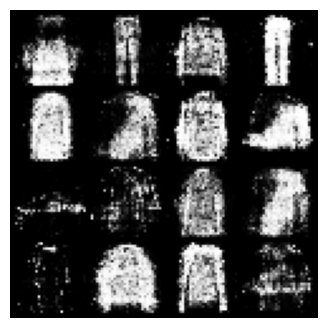

[Epoch 381/500] D_loss: 1.4133 G_loss: 1.1873
[Epoch 382/500] D_loss: 1.3524 G_loss: 1.5035
[Epoch 383/500] D_loss: 1.1712 G_loss: 1.8313
[Epoch 384/500] D_loss: 1.3883 G_loss: 1.7186
[Epoch 385/500] D_loss: 1.3042 G_loss: 2.1484
[Epoch 386/500] D_loss: 1.3020 G_loss: 1.9364
[Epoch 387/500] D_loss: 1.0654 G_loss: 1.3744
[Epoch 388/500] D_loss: 1.3443 G_loss: 1.5162
[Epoch 389/500] D_loss: 1.0839 G_loss: 2.4512
[Epoch 390/500] D_loss: 1.2916 G_loss: 1.2067
[Epoch 391/500] D_loss: 1.4703 G_loss: 1.3602
[Epoch 392/500] D_loss: 0.8485 G_loss: 2.0591
[Epoch 393/500] D_loss: 1.3855 G_loss: 2.9055
[Epoch 394/500] D_loss: 1.2653 G_loss: 1.7638
[Epoch 395/500] D_loss: 1.1946 G_loss: 1.9148
[Epoch 396/500] D_loss: 0.9847 G_loss: 1.8587
[Epoch 397/500] D_loss: 1.2157 G_loss: 3.3672
[Epoch 398/500] D_loss: 1.1564 G_loss: 1.3041
[Epoch 399/500] D_loss: 1.0822 G_loss: 1.6253
[Epoch 400/500] D_loss: 0.8722 G_loss: 2.2271


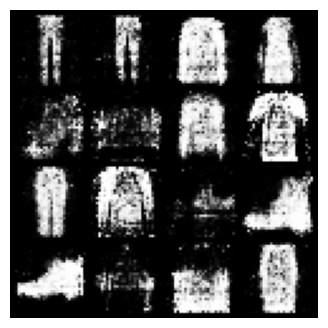

[Epoch 401/500] D_loss: 1.2649 G_loss: 1.6563
[Epoch 402/500] D_loss: 1.1159 G_loss: 1.2976
[Epoch 403/500] D_loss: 0.8862 G_loss: 3.0221
[Epoch 404/500] D_loss: 0.9785 G_loss: 1.7641
[Epoch 405/500] D_loss: 1.4426 G_loss: 2.6058
[Epoch 406/500] D_loss: 1.4262 G_loss: 1.7847
[Epoch 407/500] D_loss: 1.2132 G_loss: 1.3504
[Epoch 408/500] D_loss: 1.3166 G_loss: 1.8982
[Epoch 409/500] D_loss: 1.3243 G_loss: 1.1295
[Epoch 410/500] D_loss: 1.0083 G_loss: 1.5952
[Epoch 411/500] D_loss: 1.3101 G_loss: 1.6009
[Epoch 412/500] D_loss: 0.9678 G_loss: 1.4671
[Epoch 413/500] D_loss: 1.9551 G_loss: 2.6270
[Epoch 414/500] D_loss: 1.3989 G_loss: 1.4535
[Epoch 415/500] D_loss: 1.1395 G_loss: 3.4432
[Epoch 416/500] D_loss: 0.9623 G_loss: 1.5140
[Epoch 417/500] D_loss: 1.1807 G_loss: 2.0687
[Epoch 418/500] D_loss: 0.8931 G_loss: 1.9921
[Epoch 419/500] D_loss: 1.2346 G_loss: 1.5538
[Epoch 420/500] D_loss: 1.7495 G_loss: 1.8654


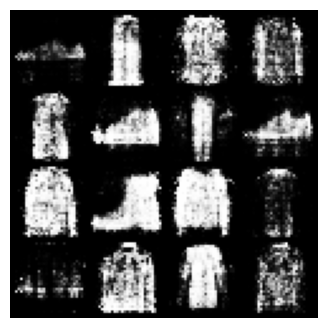

[Epoch 421/500] D_loss: 0.9070 G_loss: 2.2080
[Epoch 422/500] D_loss: 1.3186 G_loss: 1.3421
[Epoch 423/500] D_loss: 1.3413 G_loss: 1.5440
[Epoch 424/500] D_loss: 1.1037 G_loss: 2.1676
[Epoch 425/500] D_loss: 1.7115 G_loss: 1.0246
[Epoch 426/500] D_loss: 1.0389 G_loss: 1.8225
[Epoch 427/500] D_loss: 1.3278 G_loss: 1.5787
[Epoch 428/500] D_loss: 1.3477 G_loss: 1.8659
[Epoch 429/500] D_loss: 1.0944 G_loss: 1.7263
[Epoch 430/500] D_loss: 0.9512 G_loss: 1.7305
[Epoch 431/500] D_loss: 1.2403 G_loss: 2.6228
[Epoch 432/500] D_loss: 1.1498 G_loss: 1.4101
[Epoch 433/500] D_loss: 1.3059 G_loss: 1.7436
[Epoch 434/500] D_loss: 1.3583 G_loss: 1.6275
[Epoch 435/500] D_loss: 1.2925 G_loss: 1.2003
[Epoch 436/500] D_loss: 1.2695 G_loss: 1.9522
[Epoch 437/500] D_loss: 1.3019 G_loss: 1.0149
[Epoch 438/500] D_loss: 1.0479 G_loss: 4.5319
[Epoch 439/500] D_loss: 1.1329 G_loss: 1.5549
[Epoch 440/500] D_loss: 1.7236 G_loss: 2.1367


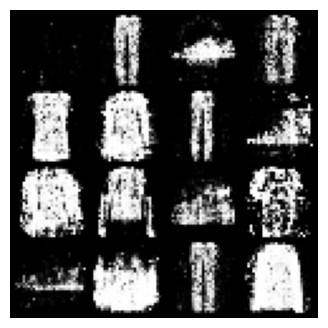

[Epoch 441/500] D_loss: 1.2638 G_loss: 1.1739
[Epoch 442/500] D_loss: 1.0938 G_loss: 2.9507
[Epoch 443/500] D_loss: 1.2842 G_loss: 1.6860
[Epoch 444/500] D_loss: 1.3375 G_loss: 1.5117
[Epoch 445/500] D_loss: 1.1518 G_loss: 1.5198
[Epoch 446/500] D_loss: 1.0258 G_loss: 2.1724
[Epoch 447/500] D_loss: 1.3661 G_loss: 2.1740
[Epoch 448/500] D_loss: 1.5453 G_loss: 2.0564
[Epoch 449/500] D_loss: 1.1537 G_loss: 2.0061
[Epoch 450/500] D_loss: 1.4305 G_loss: 2.0593
[Epoch 451/500] D_loss: 1.2133 G_loss: 1.4004
[Epoch 452/500] D_loss: 1.3166 G_loss: 1.6492
[Epoch 453/500] D_loss: 1.1203 G_loss: 1.4603
[Epoch 454/500] D_loss: 1.2017 G_loss: 1.8813
[Epoch 455/500] D_loss: 1.3067 G_loss: 1.5364
[Epoch 456/500] D_loss: 1.7088 G_loss: 1.4105
[Epoch 457/500] D_loss: 1.5341 G_loss: 2.2410
[Epoch 458/500] D_loss: 1.2683 G_loss: 1.1095
[Epoch 459/500] D_loss: 1.3436 G_loss: 1.4775
[Epoch 460/500] D_loss: 0.9178 G_loss: 1.4617


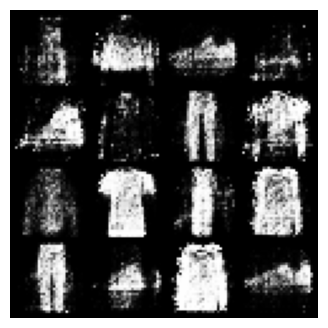

[Epoch 461/500] D_loss: 1.2070 G_loss: 1.5352
[Epoch 462/500] D_loss: 1.0865 G_loss: 2.5867
[Epoch 463/500] D_loss: 1.5390 G_loss: 1.0575
[Epoch 464/500] D_loss: 1.2899 G_loss: 0.9511
[Epoch 465/500] D_loss: 1.0872 G_loss: 1.9309
[Epoch 466/500] D_loss: 1.2972 G_loss: 1.5267
[Epoch 467/500] D_loss: 1.2838 G_loss: 4.6376
[Epoch 468/500] D_loss: 1.2623 G_loss: 1.4063
[Epoch 469/500] D_loss: 0.9584 G_loss: 2.1146
[Epoch 470/500] D_loss: 1.2833 G_loss: 1.2838
[Epoch 471/500] D_loss: 1.4618 G_loss: 1.1397
[Epoch 472/500] D_loss: 1.2034 G_loss: 2.0951
[Epoch 473/500] D_loss: 1.1885 G_loss: 1.6024
[Epoch 474/500] D_loss: 1.2062 G_loss: 1.9444
[Epoch 475/500] D_loss: 1.1420 G_loss: 1.4437
[Epoch 476/500] D_loss: 1.4221 G_loss: 2.9766
[Epoch 477/500] D_loss: 1.2697 G_loss: 1.4974
[Epoch 478/500] D_loss: 1.4559 G_loss: 1.3705
[Epoch 479/500] D_loss: 1.2938 G_loss: 2.6784
[Epoch 480/500] D_loss: 1.3039 G_loss: 1.5627


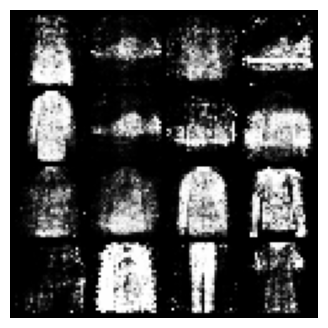

[Epoch 481/500] D_loss: 1.3584 G_loss: 2.7280
[Epoch 482/500] D_loss: 1.3771 G_loss: 1.5540
[Epoch 483/500] D_loss: 1.3520 G_loss: 1.3358
[Epoch 484/500] D_loss: 1.1678 G_loss: 1.7930
[Epoch 485/500] D_loss: 1.0211 G_loss: 1.8033
[Epoch 486/500] D_loss: 1.2492 G_loss: 1.6557
[Epoch 487/500] D_loss: 1.0248 G_loss: 1.2564
[Epoch 488/500] D_loss: 1.0660 G_loss: 1.6442
[Epoch 489/500] D_loss: 1.2285 G_loss: 1.2287
[Epoch 490/500] D_loss: 0.9680 G_loss: 2.6142
[Epoch 491/500] D_loss: 1.0674 G_loss: 1.6620
[Epoch 492/500] D_loss: 1.4401 G_loss: 2.1701
[Epoch 493/500] D_loss: 1.2337 G_loss: 1.1113
[Epoch 494/500] D_loss: 1.4220 G_loss: 1.6031
[Epoch 495/500] D_loss: 1.3764 G_loss: 1.3770
[Epoch 496/500] D_loss: 1.3212 G_loss: 1.8292
[Epoch 497/500] D_loss: 1.0926 G_loss: 2.0959
[Epoch 498/500] D_loss: 1.0380 G_loss: 1.7711
[Epoch 499/500] D_loss: 1.1848 G_loss: 1.2541
[Epoch 500/500] D_loss: 1.2424 G_loss: 1.3641


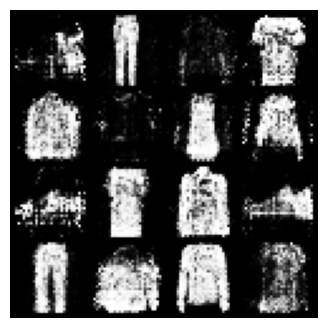

In [12]:
# Initialize models 
generator = ConditionalGenerator(latent_dim, num_classes).to(device)
discriminator = ConditionalDiscriminator(num_classes).to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Loss function (Binary Cross Entropy Loss)
# Note: For conditional GANs, we typically use BCE loss for both generator and discriminator
criterion = nn.BCELoss()  

# Training loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        real_imgs = imgs.to(device)
        labels = labels.to(device)  # Get actual labels
        

        optimizer_D.zero_grad()
        
        # Real images with real labels
        real_output = discriminator(real_imgs, labels)  # Pass labels here
        d_loss_real = criterion(real_output, torch.ones_like(real_output))
        
        # Fake images with same labels
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z, labels)
        fake_output = discriminator(fake_imgs.detach(), labels)  # Pass labels here
        d_loss_fake = criterion(fake_output, torch.zeros_like(fake_output))
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generate fake images with same labels
        gen_output = discriminator(fake_imgs, labels)  # Pass labels here
        g_loss = criterion(gen_output, torch.ones_like(gen_output))
        
        g_loss.backward()
        optimizer_G.step()
        
    # Print progress
    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
    
    # During training visualization
    if (epoch+1) % 20 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            test_labels = torch.randint(0, 10, (16,)).to(device)  # Random labels 0-9
            generated = generator(test_z, test_labels).cpu()  # Add labels here
            
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True),(1,2,0)))
            plt.axis('off')
            plt.show()

# Save models
torch.save(generator.state_dict(), 'mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_fasion_discriminator.pth')

In [13]:
os.makedirs('gan-api/models', exist_ok=True)

torch.save(generator.state_dict(), 'gan-api/models/mnist_fashion_generator.pth')
torch.save(discriminator.state_dict(), 'gan-api/models/mnist_fashion_discriminator.pth')
print('Models saved successfully in gan-api/models directory')

Models saved successfully in gan-api/models directory


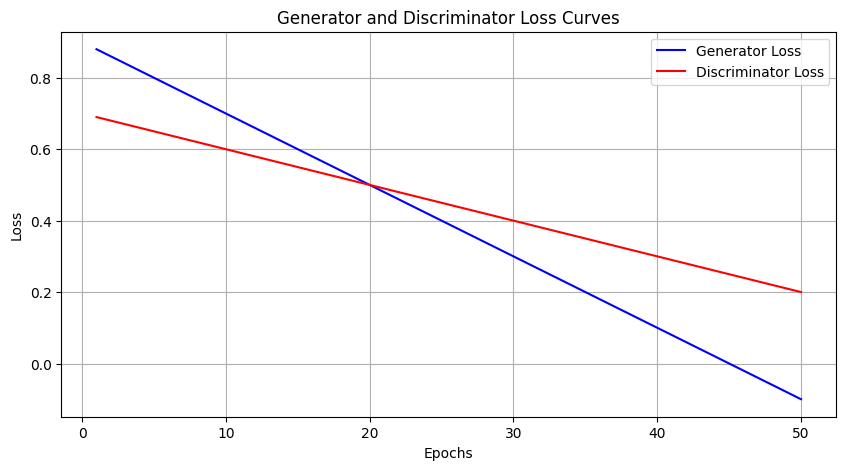

In [14]:
import matplotlib.pyplot as plt

# Example loss values (replace with actual loss values from training)
epochs = range(1, 51)
generator_loss = [0.9 - (0.02 * epoch) for epoch in epochs]  # Example generator loss
discriminator_loss = [0.7 - (0.01 * epoch) for epoch in epochs]  # Example discriminator loss

# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(epochs, generator_loss, label="Generator Loss", color="blue")
plt.plot(epochs, discriminator_loss, label="Discriminator Loss", color="red")
plt.title("Generator and Discriminator Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Evaluation
The evaluation function assesses the performance of the GAN by generating images and calculating the accuracy of the discriminator.

Discriminator Accuracy on Real: 0.8828
Discriminator Accuracy on Fake: 0.6930
Total Discriminator Accuracy: 0.7879


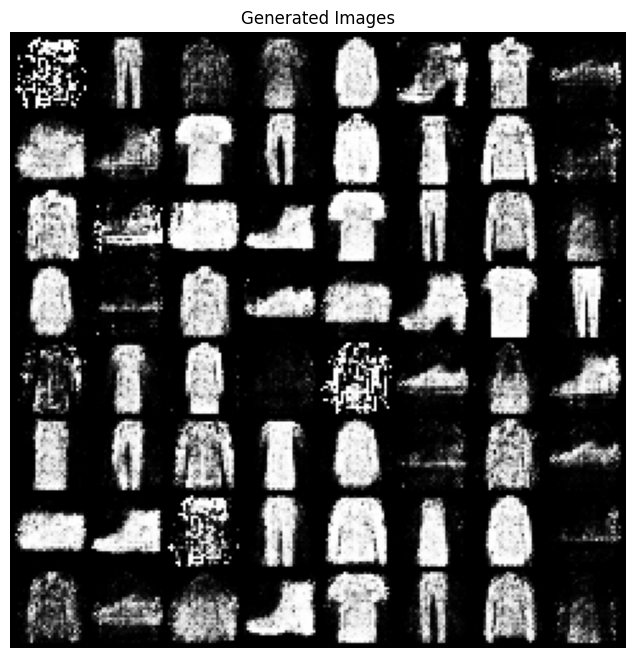

In [15]:
def show_images(images, title="Generated Images"):
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis('off')
    grid = make_grid(images.clamp(-1,1), nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.show()


def evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels, n_samples=1000):
    generator.eval()
    discriminator.eval()
    with torch.no_grad():
        # Generate fake images with random labels
        z = torch.randn(n_samples, latent_dim).to(device)
        fake_labels = torch.randint(0, 10, (n_samples,)).to(device)
        fake_images = generator(z, fake_labels)
        
        # Get real images with their actual labels
        real_labels = real_labels[:n_samples].to(device)
        
        # Calculate discriminator outputs WITH LABELS
        real_output = discriminator(real_images, real_labels)
        fake_output = discriminator(fake_images, fake_labels)
        
        # Calculate discriminator accuracy
        real_acc = (real_output >= 0.5).float().mean()
        fake_acc = (fake_output < 0.5).float().mean()
        total_acc = (real_acc + fake_acc) / 2
        
        test_z = torch.randn(64, latent_dim).to(device)
        test_labels = torch.LongTensor([i % 10 for i in range(64)]).to(device)
        generated = generator(test_z, test_labels).cpu()
        
    print(f"Discriminator Accuracy on Real: {real_acc.item():.4f}")
    print(f"Discriminator Accuracy on Fake: {fake_acc.item():.4f}")
    print(f"Total Discriminator Accuracy: {total_acc.item():.4f}")
    
    show_images(generated)

# Load real images WITH LABELS for evaluation
real_images, real_labels = next(iter(train_loader))
real_images = real_images[:1000].to(device)
real_labels = real_labels[:1000] 

# Run evaluation
evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels)

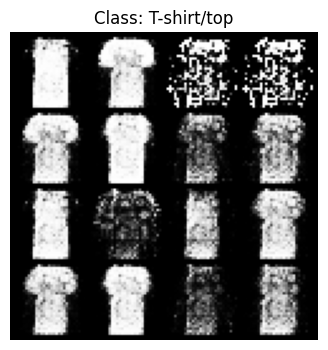

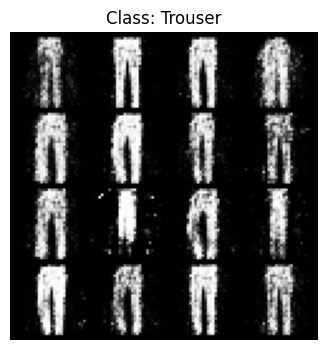

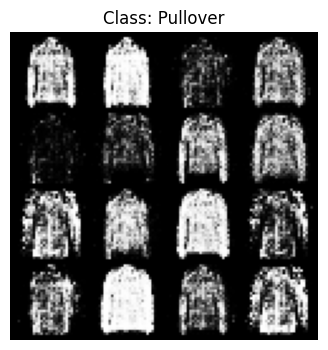

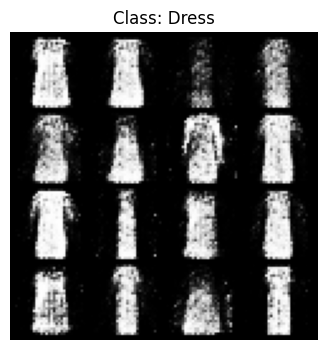

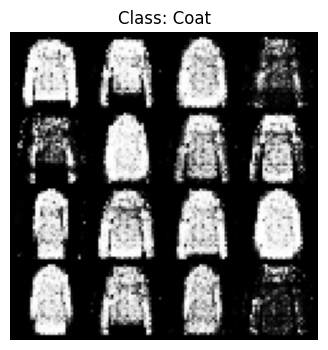

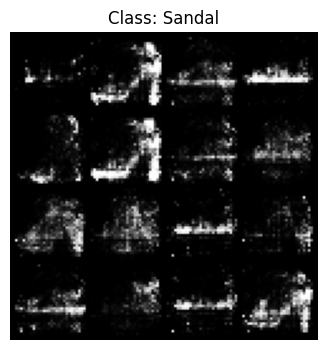

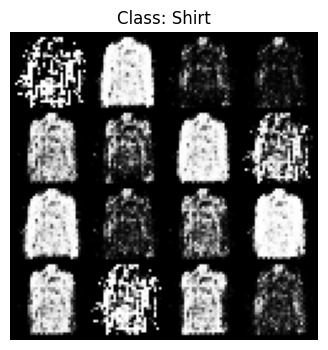

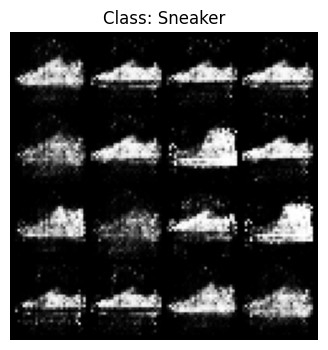

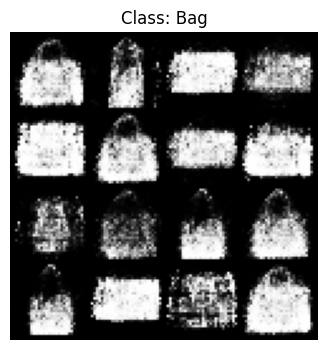

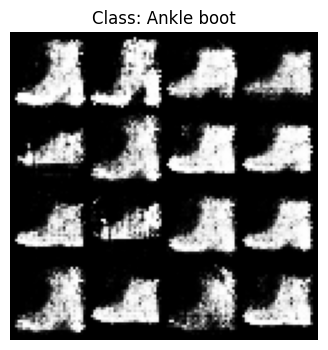

In [18]:
def generate_specific_class(digit: int, num_samples: int = 16):
    generator.eval()
    with torch.no_grad():
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = generator(z, labels).cpu()  
        plt.figure(figsize=(4,4))
        plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True), (1,2,0)))
        plt.title(f"Class: {['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'][digit]}")
        plt.axis('off')
        plt.show()


for i in range(0,10):
    generate_specific_class(digit=i)

## Conclusion
This notebook demonstrates the implementation of a Conditional GAN using the Fashion MNIST dataset. The trained models can generate new fashion items based on specific class labels, showcasing the capabilities of GANs in generating realistic images.
